# Comparison of Mean Delta Z and SNAP Correlations: BA46 vs BA11

This notebook compares the mean correlation difference (Delta Z) and SNAP-a correlations across different module sets and cohorts:
1. **BA46 (Discovery)**: Discovery cohort data with discovery modules.
2. **BA11 (Validation, de novo)**: Validation cohort data with its own de novo modules.
3. **BA11 (Validation, Transfer)**: Validation cohort data with modules transferred from the discovery cohort (BA46).

In [1]:
import os
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import scanpy as sc
from scipy.stats import pearsonr

# Add sources directory to path
sys.path.append('../../sources')
import wgcna_utils as wu
import corr_utils as cu
import snap_utils as su

plt.rcParams['font.family'] = 'Liberation Serif'

/data/home/swkim0523/.local/lib/python3.9/site-packages/setuptools_scm/version.py:11: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import iter_entry_points


In [2]:
def get_delta_z_matrix(ast_c, mic_c, ast_s, mic_s, ast_mods, mic_mods, ast_prefix='Ast', mic_prefix='Mic'):
    """
    Calculates Delta Z matrix (SCZ - Control) using library functions.
    """
    # 1. Get module means (using snap_utils)
    ast_c_means = su.get_module_means(ast_c, ast_mods, ast_prefix)
    mic_c_means = su.get_module_means(mic_c, mic_mods, mic_prefix)
    ast_s_means = su.get_module_means(ast_s, ast_mods, ast_prefix)
    mic_s_means = su.get_module_means(mic_s, mic_mods, mic_prefix)
    
    # 2. Get cross-correlation (using corr_utils)
    r_c = cu.get_cross_corr(ast_c_means, mic_c_means)
    r_s = cu.get_cross_corr(ast_s_means, mic_s_means)
    
    # 3. Calculate Delta Z (using corr_utils)
    # Note: calculate_delta_corr_significance returns (delta_z, p_values)
    # Arguments: r_scz, n_scz, r_ctrl, n_ctrl
    dz, _ = cu.calculate_delta_corr_significance(r_s, len(ast_s), r_c, len(ast_c))
    return dz

## 1. Load Data and Calculate Delta Z

We calculate the mean Delta Z for the three comparison sets.

In [3]:
# Paths
primary_path = "/data/home/swkim0523/research/_SCZ_mic_ast_fin_0511/data/primary_cohort"
val_path = "/data/home/swkim0523/research/_SCZ_mic_ast_fin_0511/data/validation_cohort/GSE254569"
output_dir = "/data/home/swkim0523/research/_SCZ_mic_ast_fin_0511/figures"
os.makedirs(output_dir, exist_ok=True)

# Load Primary Modules
ast_mods_main, _ = wu.get_module_dict('astrocyte', f"{primary_path}/WGCNA_modules/df_zsummary_astrocyte.csv", f"{primary_path}/WGCNA_modules/modules_whole_astrocyte.csv")
mic_mods_main, _ = wu.get_module_dict('microglia', f"{primary_path}/WGCNA_modules/df_zsummary_microglia.csv", f"{primary_path}/WGCNA_modules/modules_whole_microglia.csv")

# Load Validation Modules
ast_mods_val, _ = wu.get_module_dict('astrocyte', f"{val_path}/WGCNA_modules/df_zsummary_astrocyte_val.csv", f"{val_path}/WGCNA_modules/modules_whole_astrocyte_val.csv")
mic_mods_val, _ = wu.get_module_dict('microglia', f"{val_path}/WGCNA_modules/df_zsummary_microglia_val.csv", f"{val_path}/WGCNA_modules/modules_whole_microglia_val.csv")

# Load Pseudobulk Data
def load_pb(path, ct): return pd.read_csv(f"{path}/pb_ct_filtered/pb_{ct}_control_filtered.csv", index_col=0), pd.read_csv(f"{path}/pb_ct_filtered/pb_{ct}_scz_filtered.csv", index_col=0)

p_ast_c, p_ast_s = load_pb(primary_path, 'astrocyte')
p_mic_c, p_mic_s = load_pb(primary_path, 'microglia')
v_ast_c, v_ast_s = load_pb(val_path, 'Astrocytes')
v_mic_c, v_mic_s = load_pb(val_path, 'Microglia')

# Calculate Delta Z Matrices
dz_main     = get_delta_z_matrix(p_ast_c, p_mic_c, p_ast_s, p_mic_s, ast_mods_main, mic_mods_main)
dz_val      = get_delta_z_matrix(v_ast_c, v_mic_c, v_ast_s, v_mic_s, ast_mods_val, mic_mods_val)
dz_transfer = get_delta_z_matrix(v_ast_c, v_mic_c, v_ast_s, v_mic_s, ast_mods_main, mic_mods_main)

Module 1: 474 genes
Module 2: 2888 genes
Module 3: 992 genes
Module 4: 195 genes
Module 5: 74 genes
Module 7: 618 genes
Module 8: 284 genes
Module 9: 126 genes
Module 10: 165 genes
Module 11: 104 genes
Module 12: 103 genes
Module 13: 322 genes
Module 14: 180 genes
Module 15: 363 genes
Module 16: 593 genes
Module 17: 247 genes
Module 18: 251 genes
Module 19: 3575 genes
Module 20: 723 genes
Module 1: 369 genes
Module 2: 1586 genes
Module 3: 1257 genes
Module 4: 59 genes
Module 5: 66 genes
Module 6: 58 genes
Module 8: 424 genes
Module 9: 221 genes
Module 10: 104 genes
Module 11: 109 genes
Module 12: 92 genes
Module 13: 131 genes
Module 14: 326 genes
Module 15: 249 genes
Module 16: 403 genes
Module 17: 91 genes
Module 18: 154 genes
Module 19: 207 genes
Module 20: 4342 genes
Module 21: 630 genes
Module 1: 606 genes
Module 2: 1176 genes
Module 3: 998 genes
Module 4: 350 genes
Module 6: 723 genes
Module 7: 434 genes
Module 8: 234 genes
Module 9: 308 genes
Module 10: 218 genes
Module 11: 185 g

## 2. Mean Delta Z Visualization

We plot the mean Delta Z values for each astrocyte module.

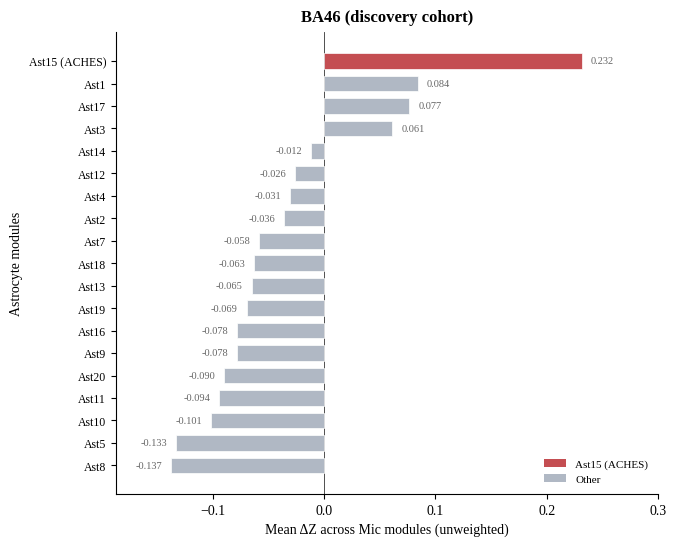

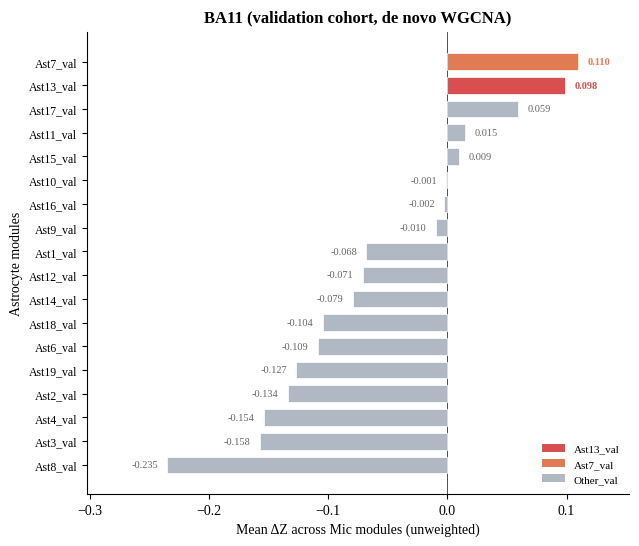

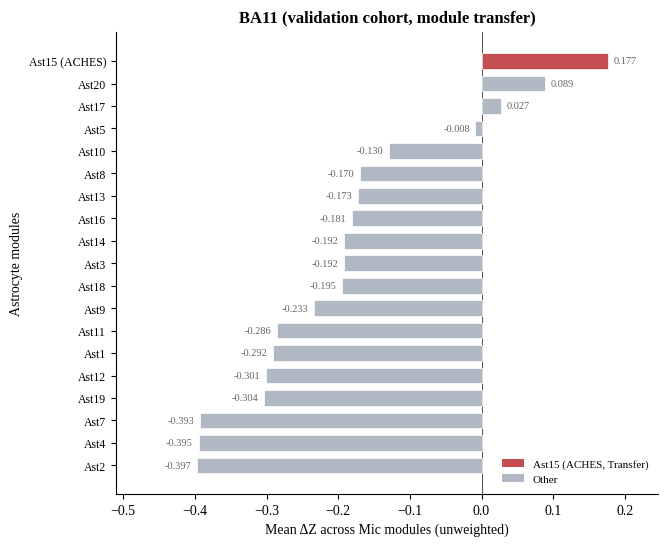

In [4]:
# Compute means
ba46_mean = dz_main.mean(axis=1).sort_values()
ba11_mean = dz_val.mean(axis=1).sort_values()
ba11_mean.index = ba11_mean.index + '_val'
transfer_mean = dz_transfer.mean(axis=1).sort_values()

# Colors and Handles
c_ast15, c_ast13, c_ast7, c_default = '#C44E52', '#D94F4F', '#E07B54', '#B0B8C4'

plot_config = [
    (ba46_mean, [c_ast15 if m == 'Ast15' else c_default for m in ba46_mean.index], 
     'BA46 (discovery cohort)', {'Ast15': c_ast15}, 'fig5a_delta_z_main', 
     [Patch(facecolor=c_ast15, label='Ast15 (ACHES)'), Patch(facecolor=c_default, label='Other')]),
    
    (ba11_mean, [{'Ast13_val': c_ast13, 'Ast7_val': c_ast7}.get(m, c_default) for m in ba11_mean.index], 
     'BA11 (validation cohort, de novo WGCNA)', {'Ast13_val': c_ast13, 'Ast7_val': c_ast7}, 'fig5e_delta_z_val', 
     [Patch(facecolor=c_ast13, label='Ast13_val'), Patch(facecolor=c_ast7, label='Ast7_val'), Patch(facecolor=c_default, label='Other_val')]),
    
    (transfer_mean, [c_ast15 if m == 'Ast15' else c_default for m in transfer_mean.index], 
     'BA11 (validation cohort, module transfer)', {'Ast15': c_ast15}, 'fig5b_delta_z_transfer', 
     [Patch(facecolor=c_ast15, label='Ast15 (ACHES, Transfer)'), Patch(facecolor=c_default, label='Other')])
]

for data, colors, title, highlights, save_name, handles in plot_config:
    fig, ax = plt.subplots(figsize=(7, 6))
    data = data.rename({'Ast15':'Ast15 (ACHES)'})
    ax.barh(range(len(data)), data.values, color=colors, edgecolor='white', linewidth=0.5, height=0.7)
    ax.set_yticks(range(len(data)))
    ax.set_yticklabels(data.index, fontsize=8.5)
    ax.axvline(0, color='#333333', linewidth=0.6, zorder=0)

    for i, (mod, val) in enumerate(data.items()):
        ax.text(val + (0.008 if val >= 0 else -0.008), i, f'{val:.3f}', va='center', 
                ha='left' if val >= 0 else 'right', fontsize=7.5,
                fontweight='bold' if mod in highlights else 'normal', color=highlights.get(mod, '#666666'))

    ax.set_title(title, fontsize=12, fontweight='bold', pad=8)
    ax.set_xlabel('Mean ΔZ across Mic modules (unweighted)', fontsize=10)
    ax.set_ylabel('Astrocyte modules', fontsize=10)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    xmin, xmax = ax.get_xlim()
    ax.set_xlim(xmin * 1.2 if xmin < 0 else 0, xmax * 1.2 if xmax > 0 else 0)
    ax.legend(handles=handles, loc='lower right', fontsize=8, frameon=False)
    plt.savefig(os.path.join(output_dir, f'{save_name}.png'), dpi=300, bbox_inches='tight')
    plt.savefig(os.path.join(output_dir, f'{save_name}.svg'), dpi=300, bbox_inches='tight')
    plt.savefig(os.path.join(output_dir, f'{save_name}.pdf'), dpi=300, bbox_inches='tight')
    plt.show()

## 3. SNAP-a Correlation Comparison (Validation Cohort)

We compare the correlation between SNAP-a scores and astrocyte module scores (Ast15, Ast13_val, Ast7_val) in the validation cohort.

[module 1] used 264/474 genes.
[module 2] used 2638/2888 genes.
[module 3] used 936/992 genes.
[module 4] used 194/195 genes.
[module 5] used 74/74 genes.
[module 7] used 598/618 genes.
[module 8] used 279/284 genes.
[module 9] used 117/126 genes.
[module 10] used 139/165 genes.
[module 11] used 102/104 genes.
[module 12] used 99/103 genes.
[module 13] used 298/322 genes.
[module 14] used 163/180 genes.
[module 15] used 336/363 genes.
[module 16] used 516/593 genes.
[module 17] used 238/247 genes.
[module 18] used 224/251 genes.
[module 19] used 3421/3575 genes.
[module 20] used 604/723 genes.
[module 1] used 264/474 genes.
[module 2] used 2638/2888 genes.
[module 3] used 936/992 genes.
[module 4] used 194/195 genes.
[module 5] used 74/74 genes.
[module 7] used 598/618 genes.
[module 8] used 279/284 genes.
[module 9] used 117/126 genes.
[module 10] used 139/165 genes.
[module 11] used 102/104 genes.
[module 12] used 99/103 genes.
[module 13] used 298/322 genes.
[module 14] used 163/180

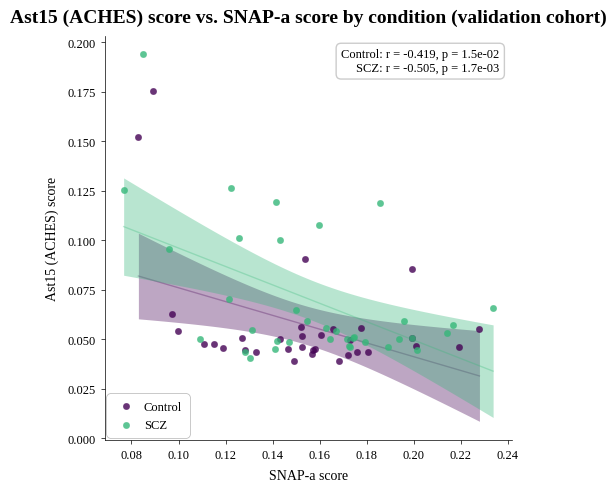

         Ast1      Ast2      Ast3      Ast4      Ast6      Ast7      Ast8  \
s6   0.023877  0.059511  0.364893  0.025636  0.066457  0.155192  0.042186   
s9   0.031399  0.108048  0.302553  0.036662  0.153550  0.225438  0.030222   
s10  0.027529  0.075002  0.323657  0.029507  0.083105  0.163105  0.043935   
s12  0.028875  0.091922  0.288315  0.025363  0.116892  0.238981  0.030342   
s16  0.031935  0.083704  0.289558  0.027547  0.090555  0.170124  0.041064   
..        ...       ...       ...       ...       ...       ...       ...   
s82  0.030983  0.079414  0.300078  0.028067  0.083220  0.171772  0.042522   
s84  0.031730  0.094596  0.271407  0.028797  0.098409  0.180884  0.033023   
s85  0.029502  0.074217  0.299175  0.024295  0.080194  0.166962  0.043557   
s86  0.028355  0.073555  0.326212  0.027215  0.079144  0.164732  0.046994   
s87  0.052828  0.118313  0.253330  0.034890  0.120814  0.213470  0.020179   

         Ast9     Ast10     Ast11     Ast12     Ast13     Ast14     Ast15  

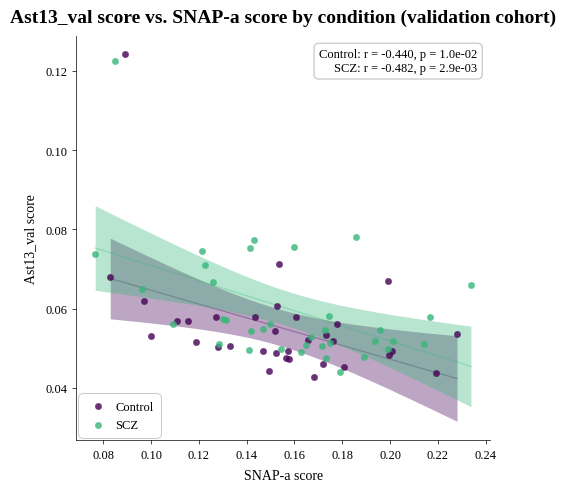

         Ast1      Ast2      Ast3      Ast4      Ast6      Ast7      Ast8  \
s6   0.023877  0.059511  0.364893  0.025636  0.066457  0.155192  0.042186   
s9   0.031399  0.108048  0.302553  0.036662  0.153550  0.225438  0.030222   
s10  0.027529  0.075002  0.323657  0.029507  0.083105  0.163105  0.043935   
s12  0.028875  0.091922  0.288315  0.025363  0.116892  0.238981  0.030342   
s16  0.031935  0.083704  0.289558  0.027547  0.090555  0.170124  0.041064   
..        ...       ...       ...       ...       ...       ...       ...   
s82  0.030983  0.079414  0.300078  0.028067  0.083220  0.171772  0.042522   
s84  0.031730  0.094596  0.271407  0.028797  0.098409  0.180884  0.033023   
s85  0.029502  0.074217  0.299175  0.024295  0.080194  0.166962  0.043557   
s86  0.028355  0.073555  0.326212  0.027215  0.079144  0.164732  0.046994   
s87  0.052828  0.118313  0.253330  0.034890  0.120814  0.213470  0.020179   

         Ast9     Ast10     Ast11     Ast12     Ast13     Ast14     Ast15  

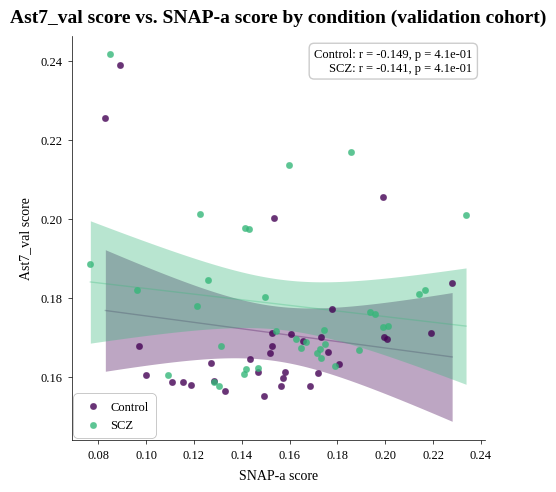

In [5]:
# Load SNAP loadings
loadings = pd.read_excel('/data/home/swkim0523/research/_SCZ_mic_ast_defense/data/SNAP_loadings/41586_2024_7109_MOESM10_ESM.xlsx', sheet_name='Gene loadings', index_col='Gene')

# Load BA11 AnnData
ad_c = sc.read_h5ad(f"{val_path}/pb_ct_filtered/pb_Astrocytes_control_filtered.h5ad")
ad_s = sc.read_h5ad(f"{val_path}/pb_ct_filtered/pb_Astrocytes_scz_filtered.h5ad")

# Calculate SNAP scores
su.snap_score_calc(ad_c, loadings)
su.snap_score_calc(ad_s, loadings)

# Calculate Module Scores
m_transfer_c, m_transfer_s = su.get_module_means(ad_c.to_df(), ast_mods_main), su.get_module_means(ad_s.to_df(), ast_mods_main)
m_val_c, m_val_s           = su.get_module_means(ad_c.to_df(), ast_mods_val), su.get_module_means(ad_s.to_df(), ast_mods_val)

# Plotting
palette = {"Control": "#440154", "SCZ": "#35B779"}
targets = [
    (m_transfer_c, m_transfer_s, 'Ast15', 'fig5c_ast15_snapa_val_scatter'),
    (m_val_c, m_val_s, 'Ast13', 'fig5f_ast13val_snapa_val_scatter'),
    (m_val_c, m_val_s, 'Ast7', 'ast7_snapa_val_scatter')
]

for mc, ms, y_col, save_name in targets:
    # Prepare plot DF
    df = pd.concat([
        mc.assign(SNAP_a=ad_c.obs['SNAP_a_score'], Condition='Control'),
        ms.assign(SNAP_a=ad_s.obs['SNAP_a_score'], Condition='SCZ')
    ])
    print(df)
    # Customize display name for validation-derived modules
    display_name = y_col
    if y_col in ['Ast13', 'Ast7']:
        display_name = f"{y_col}_val"
        df = df.rename(columns={y_col: display_name})
    # if y_col == 'Ast15':
    #     df = df.rename(columns={'Ast15':'Ast15 (ACHES)'})
    
    # Calculate stats
    stats = {c: pearsonr(df[df['Condition']==c]['SNAP_a'], df[df['Condition']==c][display_name]) for c in ['Control', 'SCZ']}
    
    # Plot using su.plot_snap_ast_scatter (uses display_name for title and y-axis)
    if save_name == 'fig5c_ast15_snapa_val_scatter':
        su.plot_snap_ast_scatter(df, 'SNAP_a', display_name, 'Condition', stats, palette, title='Ast15 (ACHES) score vs. SNAP-a score by condition (validation cohort)', 
                             output_path=os.path.join(output_dir, save_name))
    elif save_name == 'fig5f_ast13val_snapa_val_scatter':
        su.plot_snap_ast_scatter(df, 'SNAP_a', display_name, 'Condition', stats, palette, title='Ast13_val score vs. SNAP-a score by condition (validation cohort)', 
                             output_path=os.path.join(output_dir, save_name))
    elif save_name == 'ast7_snapa_val_scatter':
        su.plot_snap_ast_scatter(df, 'SNAP_a', display_name, 'Condition', stats, palette, title='Ast7_val score vs. SNAP-a score by condition (validation cohort)', 
                             output_path=os.path.join(output_dir, save_name))


[module 1] used 264/474 genes.
[module 2] used 2638/2888 genes.
[module 3] used 936/992 genes.
[module 4] used 194/195 genes.
[module 5] used 74/74 genes.
[module 7] used 598/618 genes.
[module 8] used 279/284 genes.
[module 9] used 117/126 genes.
[module 10] used 139/165 genes.
[module 11] used 102/104 genes.
[module 12] used 99/103 genes.
[module 13] used 298/322 genes.
[module 14] used 163/180 genes.
[module 15] used 336/363 genes.
[module 16] used 516/593 genes.
[module 17] used 238/247 genes.
[module 18] used 224/251 genes.
[module 19] used 3421/3575 genes.
[module 20] used 604/723 genes.
[module 1] used 264/474 genes.
[module 2] used 2638/2888 genes.
[module 3] used 936/992 genes.
[module 4] used 194/195 genes.
[module 5] used 74/74 genes.
[module 7] used 598/618 genes.
[module 8] used 279/284 genes.
[module 9] used 117/126 genes.
[module 10] used 139/165 genes.
[module 11] used 102/104 genes.
[module 12] used 99/103 genes.
[module 13] used 298/322 genes.
[module 14] used 163/180

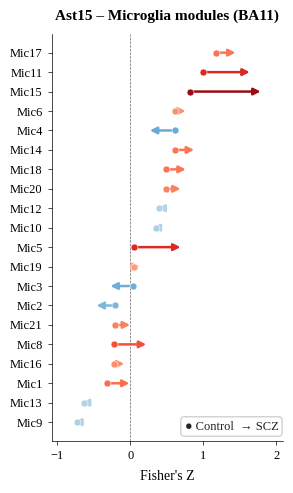

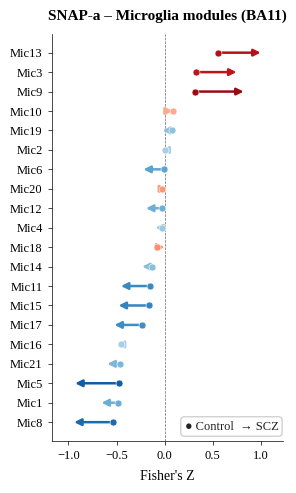

In [6]:
import numpy as np
import pandas as pd
from scipy.stats import pearsonr

# 1. Fisher Z 변환 및 Correlation Shift 계산을 위한 헬퍼 함수 정의
def fisher_z(r):
    """
    Fisher Z-transformation of correlation coefficient.
    """
    r = np.clip(r, -0.999999, 0.999999)
    return 0.5 * np.log((1 + r) / (1 - r))

def get_z_series(marker_ctrl, marker_scz, mic_ctrl, mic_scz):
    """
    각 microglia module에 대해 marker score와 pearson correlation을 구하고 Fisher Z 변환을 적용합니다.
    """
    common_ctrl = marker_ctrl.index.intersection(mic_ctrl.index)
    common_scz = marker_scz.index.intersection(mic_scz.index)
    
    z_ctrl = {}
    z_scz = {}
    
    for col in mic_ctrl.columns:
        r_c, _ = pearsonr(marker_ctrl.loc[common_ctrl], mic_ctrl.loc[common_ctrl, col])
        r_s, _ = pearsonr(marker_scz.loc[common_scz], mic_scz.loc[common_scz, col])
        z_ctrl[col] = fisher_z(r_c)
        z_scz[col] = fisher_z(r_s)
        
    return pd.Series(z_ctrl), pd.Series(z_scz)

# 2. BA11 cohort의 Astrocyte 및 Microglia 모듈 평균 계산 (Primary gene set 사용)
# 노트북에 이미 로드된 ast_mods_main, mic_mods_main 및 v_ast, v_mic 데이터를 사용합니다.
ast_control_means_val = su.get_module_means(v_ast_c, ast_mods_main, 'Ast')
ast_scz_means_val = su.get_module_means(v_ast_s, ast_mods_main, 'Ast')

mic_control_means_val = su.get_module_means(v_mic_c, mic_mods_main, 'Mic')
mic_scz_means_val = su.get_module_means(v_mic_s, mic_mods_main, 'Mic')

# 3. fig3a_ast15_mic_arrow (Ast15 - Mic shift) 계산 및 시각화
z_ast_ctrl_val, z_ast_scz_val = get_z_series(
    ast_control_means_val["Ast15"], 
    ast_scz_means_val["Ast15"], 
    mic_control_means_val, 
    mic_scz_means_val
)

su.plot_correlation_shift_arrows(
    z_ast_ctrl_val, z_ast_scz_val, 
    title="Ast15 – Microglia modules (BA11)",
    output_path=f"{output_dir}/fig3a_ast15_mic_arrow_val"
)

# 4. fig3b_snapa_mic_arrow (SNAP-a - Mic shift) 계산 및 시각화
# 이미 노트북 상단에서 ad_c, ad_s에 snap_score_calc가 완료되어 obs['SNAP_a_score']가 존재합니다.
z_snap_ctrl_val, z_snap_scz_val = get_z_series(
    ad_c.obs["SNAP_a_score"], 
    ad_s.obs["SNAP_a_score"], 
    mic_control_means_val, 
    mic_scz_means_val
)

su.plot_correlation_shift_arrows(
    z_snap_ctrl_val, z_snap_scz_val, 
    title="SNAP-a – Microglia modules (BA11)",
    output_path=f"{output_dir}/fig3b_snapa_mic_arrow_val"
)


In [7]:
z_ast_ctrl_val

Mic1    -0.311727
Mic2    -0.206907
Mic3     0.045263
Mic4     0.612922
Mic5     0.057507
Mic6     0.617835
Mic8    -0.221402
Mic9    -0.733114
Mic10    0.354173
Mic11    1.001539
Mic12    0.394822
Mic13   -0.636784
Mic14    0.609866
Mic15    0.813133
Mic16   -0.225714
Mic17    1.169211
Mic18    0.488382
Mic19    0.056543
Mic20    0.485215
Mic21   -0.212584
dtype: float64

In [8]:
z_ast_scz_val

Mic1    -0.009725
Mic2    -0.460128
Mic3    -0.270528
Mic4     0.269685
Mic5     0.689675
Mic6     0.758183
Mic8     0.219824
Mic9    -0.766844
Mic10    0.306967
Mic11    1.638110
Mic12    0.373439
Mic13   -0.662520
Mic14    0.876130
Mic15    1.787018
Mic16   -0.081264
Mic17    1.443097
Mic18    0.761798
Mic19    0.132189
Mic20    0.690884
Mic21   -0.000535
dtype: float64

In [9]:
z_snap_ctrl_val

Mic1    -0.483477
Mic2     0.001967
Mic3     0.326680
Mic4    -0.031431
Mic5    -0.477404
Mic6    -0.010458
Mic8    -0.533467
Mic9     0.310802
Mic10    0.083267
Mic11   -0.153815
Mic12   -0.027963
Mic13    0.551141
Mic14   -0.126222
Mic15   -0.158223
Mic16   -0.454757
Mic17   -0.234345
Mic18   -0.082307
Mic19    0.071910
Mic20   -0.023565
Mic21   -0.460781
dtype: float64

In [10]:
z_snap_scz_val

Mic1    -0.656107
Mic2    -0.033478
Mic3     0.746399
Mic4    -0.097562
Mic5    -0.929309
Mic6    -0.220110
Mic8    -0.939891
Mic9     0.820663
Mic10    0.084808
Mic11   -0.453689
Mic12   -0.193580
Mic13    0.997060
Mic14   -0.233345
Mic15   -0.478248
Mic16   -0.497224
Mic17   -0.521289
Mic18   -0.002175
Mic19   -0.022816
Mic20    0.026511
Mic21   -0.594609
dtype: float64